In [1]:
# Autoreload all modules so that changes in the code are reflected without needing to restart the kernel
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

# CHANGE THIS PATH TO YOUR LOCAL REPO ROOT
repo_root = Path(r"C:\Users\zhaoz\Desktop\Research\Cooperation\coop_ephys_analysis")
sys.path.append(str(repo_root))
sys.path.append(str(repo_root / "src"))

from coop_ephys_analysis.behavior import ecu_extraction as extract
from coop_ephys_analysis.behavior import behavior_qc as qc

In [3]:
# Load the extracted behaviors 
# CHANGE THIS PATH TO THE FOLDER WHERE YOUR STAGE 4 BEHAVIOR PICKLES ARE STORED
stage4_behaviors = extract.load_stage_pickles(r"C:\Users\zhaoz\Desktop\Research\Cooperation\coop_ephys_analysis\data\processed\stage4_behaviors", stage=4)
print(stage4_behaviors[0])  # Print the keys to see the structure of the loaded data

{'20250508_100203_Stage4_D1_1-2_merged': {'selfish light': [[47.44435, 52.4442], [54.48395, 59.48405], [69.57465, 74.57435], [76.06425, 81.0643], [83.27445, 88.2744], [92.2647, 97.2645], [100.65455, 105.6546], [110.05475, 115.05495], [117.51475, 122.5149], [126.27485, 131.2749], [135.25535, 140.25505], [147.7151, 152.7152], [160.91525, 165.9155], [169.0854, 174.0857], [177.2555, 182.2557], [187.546, 192.54555], [196.2057, 201.2062], [204.58595, 209.5859], [212.02595, 217.026], [222.44605, 227.44635], [234.1962, 239.19625], [243.08655, 248.08635], [250.3164, 255.31635], [257.8965, 262.89655], [266.6166, 271.6169], [273.98685, 278.98675], [282.0568, 287.05685], [289.647, 294.64695], [302.68705, 307.6875], [309.95715, 314.95735], [318.14725, 323.1474], [326.23735, 331.2374], [353.9477, 358.94775], [361.4879, 366.48785], [375.11845, 380.118], [397.8082, 402.8084], [403.9483, 408.9486], [410.5684, 415.56845], [418.4785, 423.4788], [430.27865, 435.27885], [485.7793, 490.7794], [494.62945, 49

# Min ITI & Min Bout
## 1. Event Durations

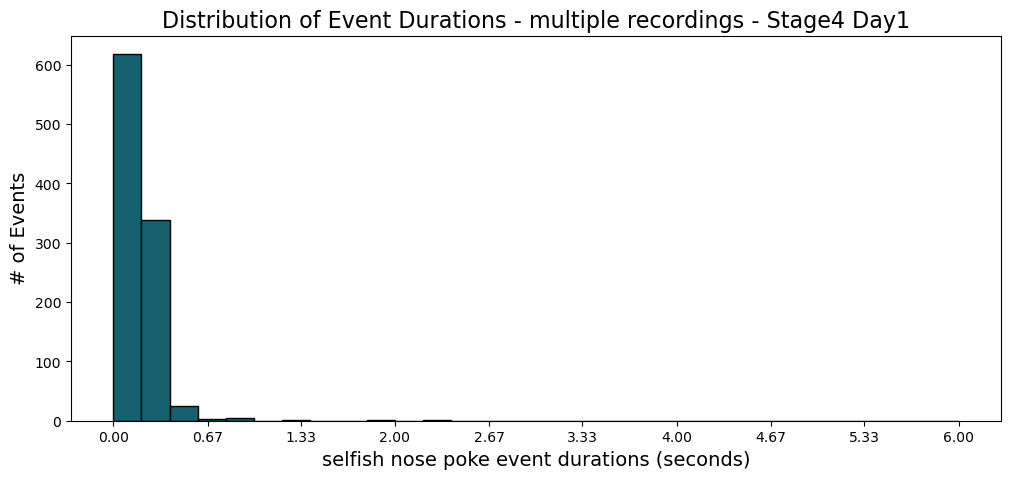

In [4]:
qc.events_duration_distribution(stage4_behaviors[0], 
								behavior='selfish nose poke', 
								stage=4, 
								day=1)

## 2. Between-Event Durations

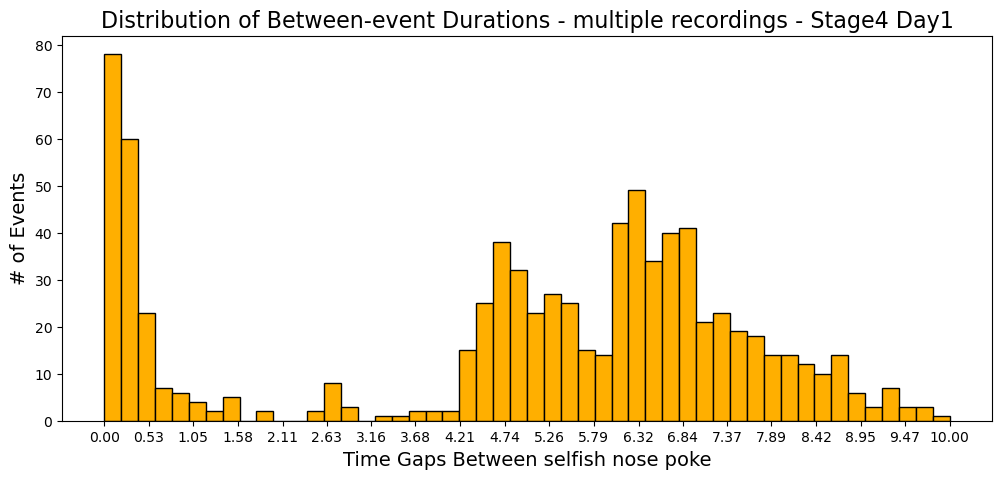

In [5]:
qc.between_events_duration_distribution(stage4_behaviors[0],
										behaviors=['selfish nose poke'], 
										stage=4, 
										day=1)

## 3. Process for Min ITI and Length
### Before

Stage 4 Day 1
--------------------
20250508_100203_Stage4_D1_1-2_merged
# selfish light - 178
# coop nose poke - 136
# recipient port entry - 139
# coop light - 125
# selfish nose poke - 60
# subject port entry - 323

20250508_100203_Stage4_D1_1-3_merged
# selfish light - 178
# coop nose poke - 136
# recipient port entry - 139
# coop light - 125
# selfish nose poke - 60
# subject port entry - 323

20250508_100203_Stage4_D1_2-1_merged
# selfish nose poke - 86
# subject port entry - 272
# coop nose poke - 89
# selfish light - 151
# recipient port entry - 354
# coop light - 82

20250508_100203_Stage4_D1_2-4_merged
# selfish nose poke - 86
# subject port entry - 272
# coop nose poke - 89
# selfish light - 151
# recipient port entry - 354
# coop light - 82

20250508_112121_Stage4_D1_6-1_merged
# selfish light - 190
# coop nose poke - 164
# recipient port entry - 1
# coop light - 147
# selfish nose poke - 60
# subject port entry - 690

20250508_112121_Stage4_D1_6-3_merged
# selfish nose poke

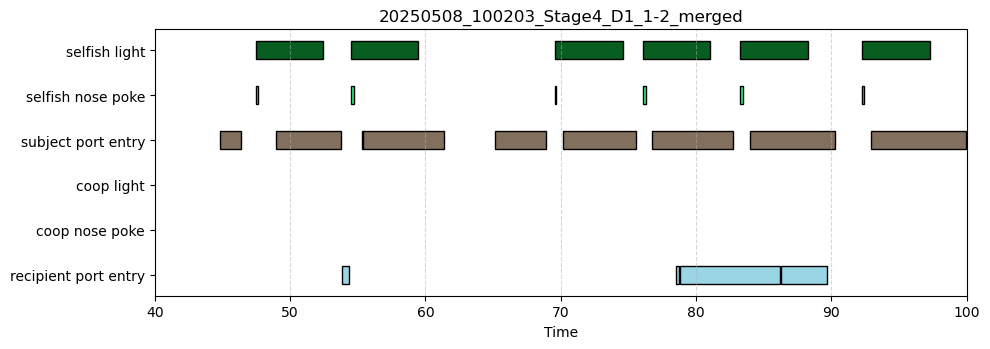

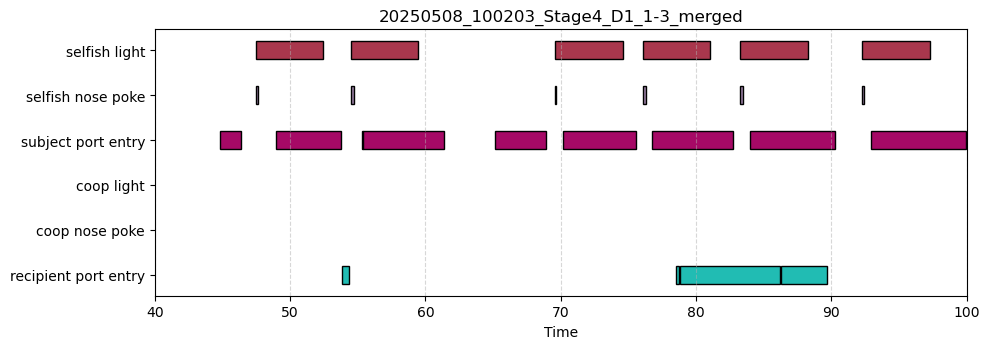

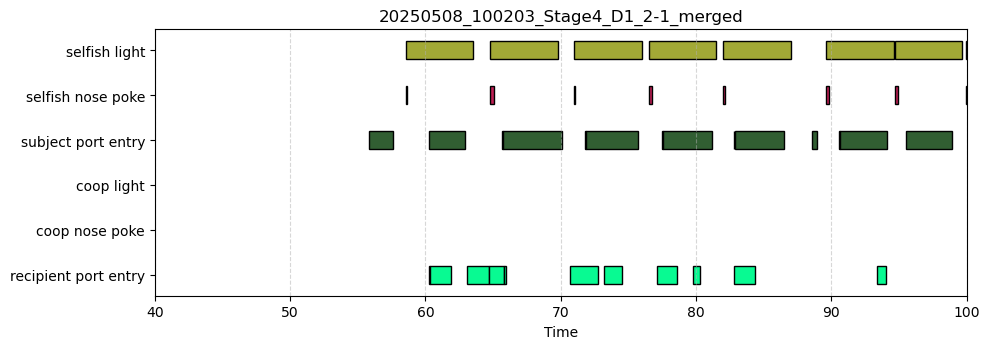

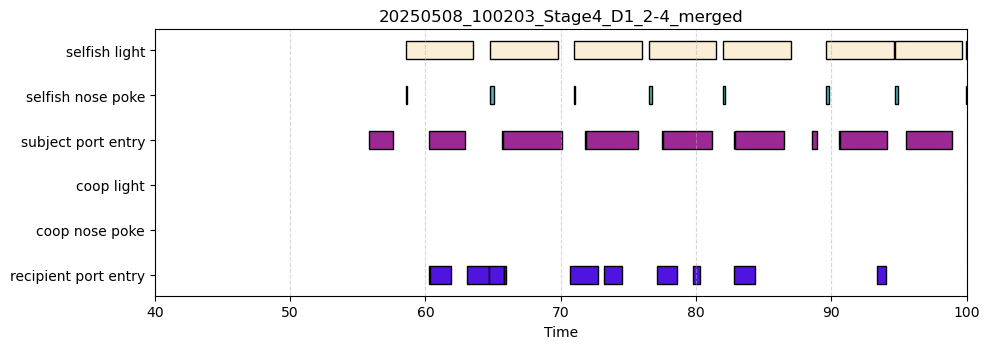

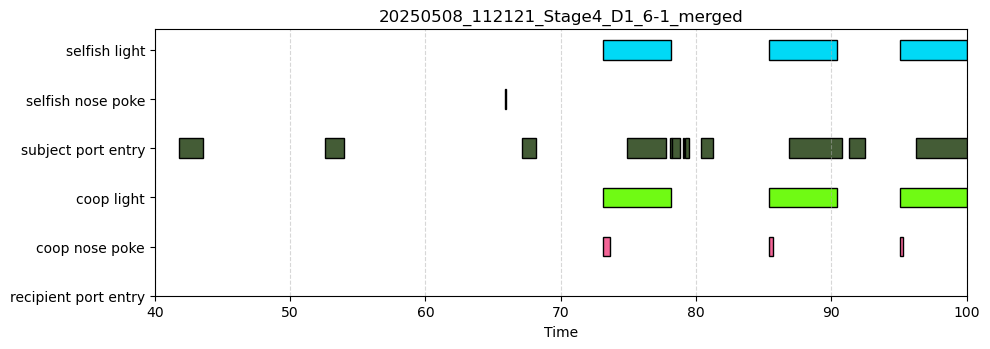

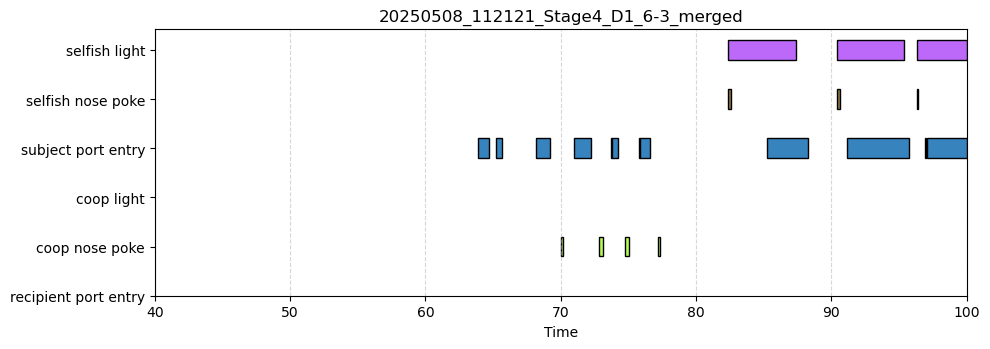

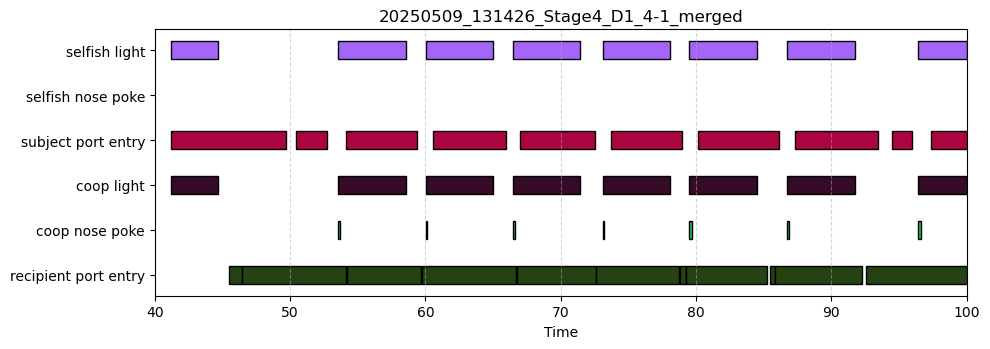

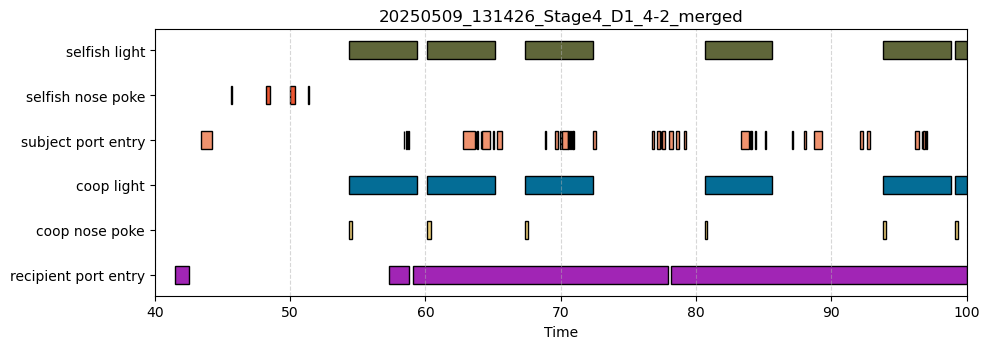

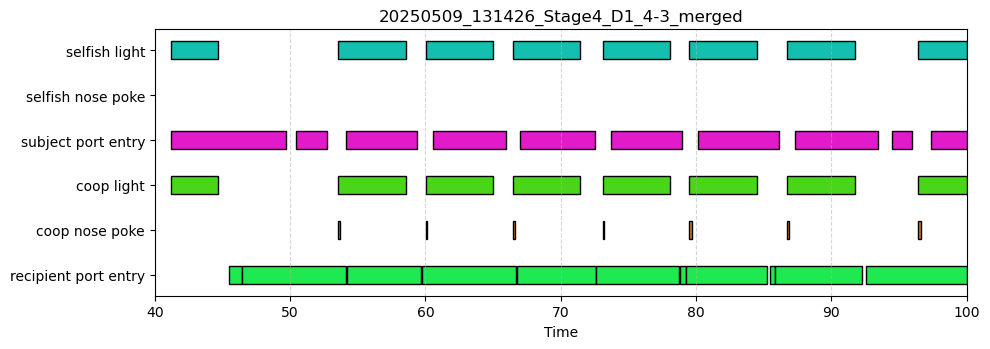

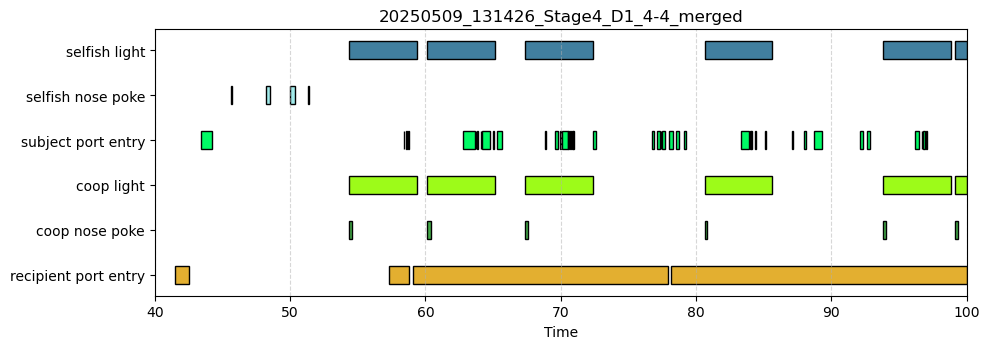

In [6]:
# How the data looks like BEFORE processing
qc.count_events(stage4_behaviors[0],
				stage=4,
				day=1)
qc.plot_recordings_behaviors(stage4_behaviors,
							 time_window=(40, 100),
							 day=1)

### Threshold

In [7]:
# Min iti of 1s for selfish and coop nose pokes
stage4_behaviors = qc.threshold_stage_behaviors(stage4_behaviors,
							 behaviors=['selfish nose poke', 'coop nose poke'],
							 min_iti=1,
							 min_bout=0)

# Min iti of 0.8s and min bout of 1s for subject port entry
stage4_behaviors = qc.threshold_stage_behaviors(stage4_behaviors,
												behaviors=['subject port entry'],
												min_iti=0.8,
												min_bout=1)

# Min iti of 0.1s for recipient port entry
stage4_behaviors = qc.threshold_stage_behaviors(stage4_behaviors,
												behaviors=['recipient port entry'],
												min_iti=0.1,
												min_bout=0)

### After

Stage 4 Day 1
--------------------
20250508_100203_Stage4_D1_1-2_merged
# selfish light - 178
# coop nose poke - 129
# recipient port entry - 114
# coop light - 125
# selfish nose poke - 56
# subject port entry - 205

20250508_100203_Stage4_D1_1-3_merged
# selfish light - 178
# coop nose poke - 129
# recipient port entry - 114
# coop light - 125
# selfish nose poke - 56
# subject port entry - 205

20250508_100203_Stage4_D1_2-1_merged
# selfish nose poke - 80
# subject port entry - 180
# coop nose poke - 84
# selfish light - 151
# recipient port entry - 225
# coop light - 82

20250508_100203_Stage4_D1_2-4_merged
# selfish nose poke - 80
# subject port entry - 180
# coop nose poke - 84
# selfish light - 151
# recipient port entry - 225
# coop light - 82

20250508_112121_Stage4_D1_6-1_merged
# selfish light - 190
# coop nose poke - 155
# recipient port entry - 1
# coop light - 147
# selfish nose poke - 52
# subject port entry - 261

20250508_112121_Stage4_D1_6-3_merged
# selfish nose poke

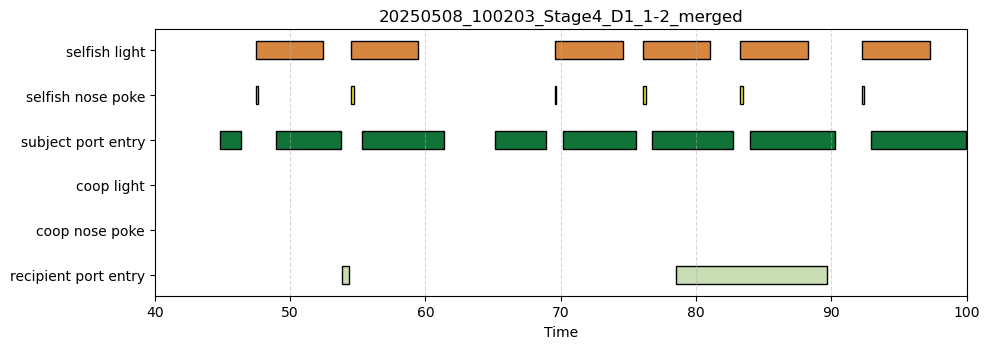

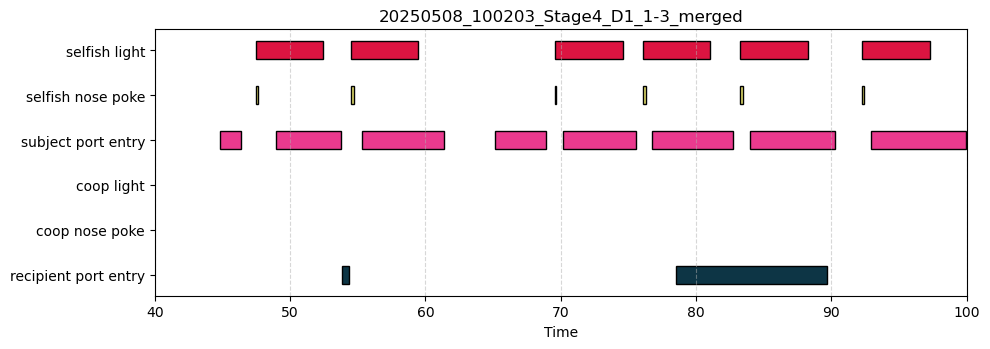

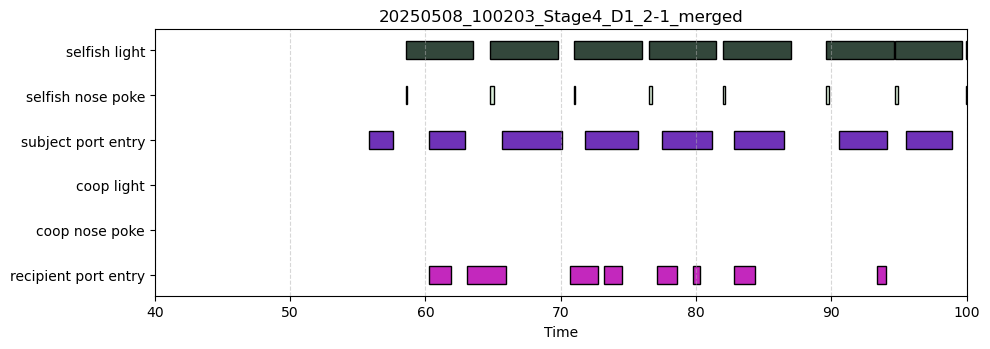

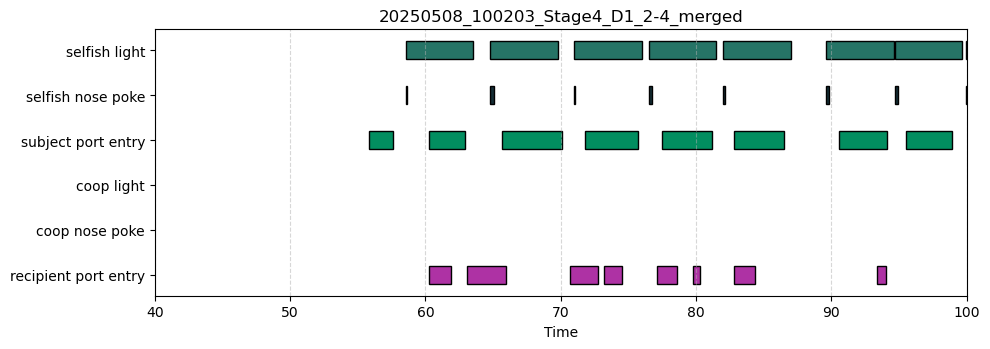

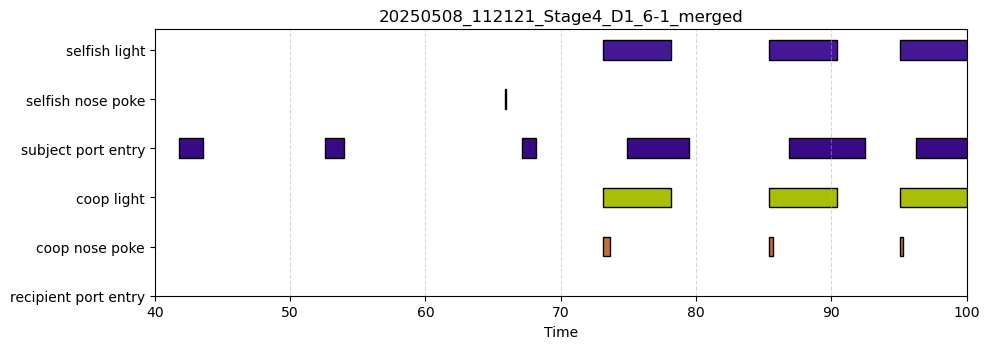

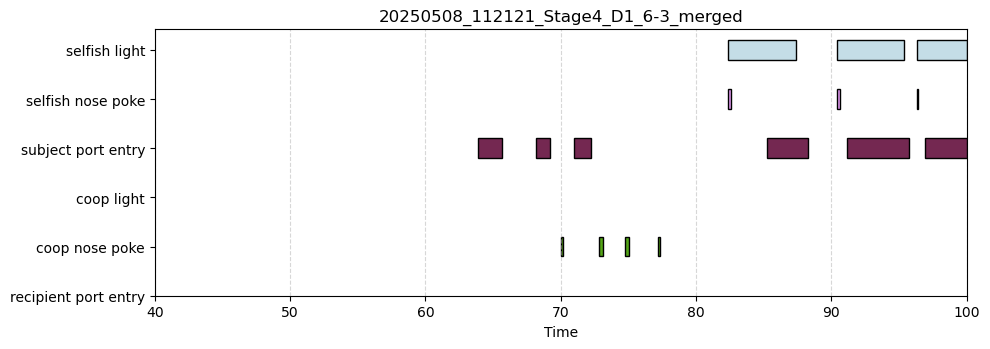

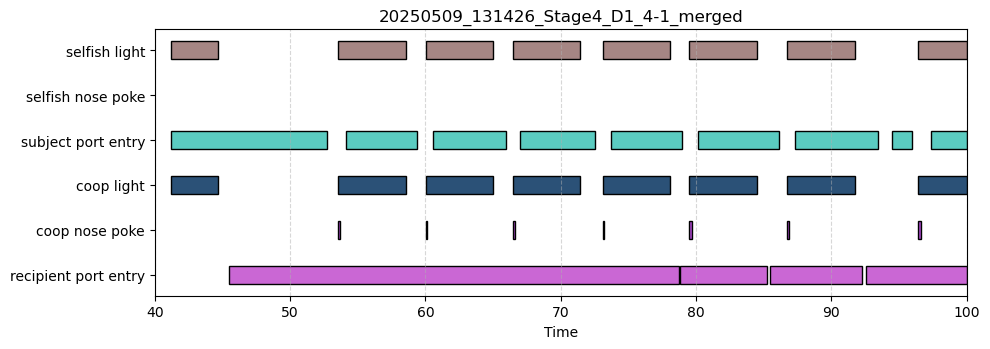

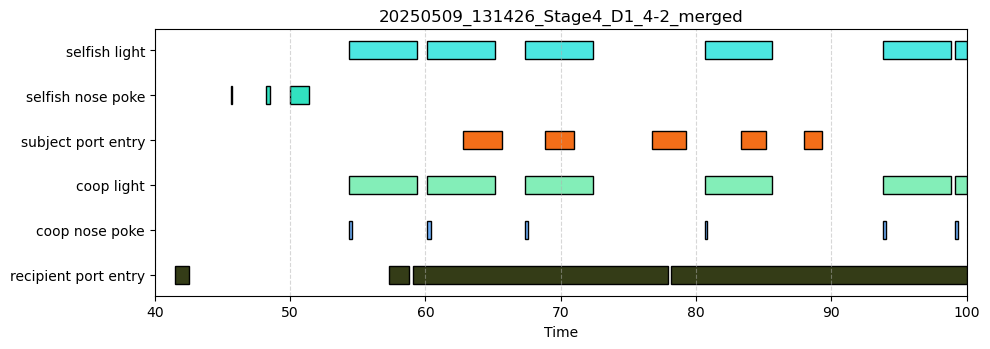

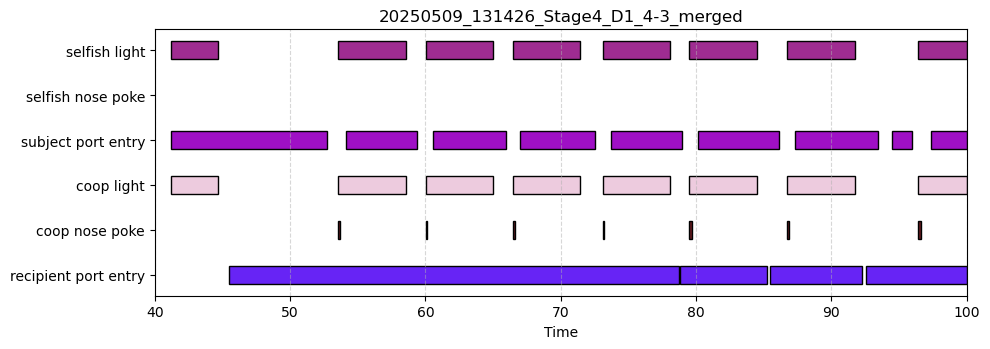

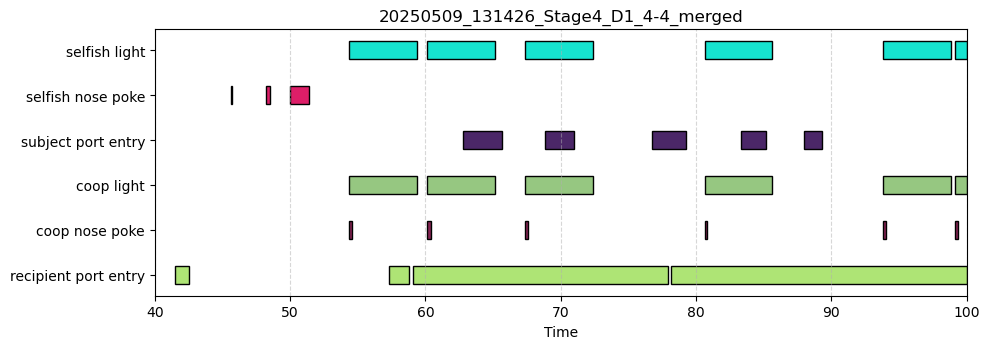

In [8]:
# How the data looks like AFTER processing
qc.count_events(stage4_behaviors[0],
				stage=4,
				day=1)
qc.plot_recordings_behaviors(stage4_behaviors,
							 time_window=(40, 100),
							 day=1)

## 4. Pickle the Processed Behaviors

In [ ]:
extract.save_stage_pickles(stage4_behaviors,
						   r'C:\Users\zhaoz\Desktop\Research\Cooperation\coop_ephys_analysis\data\processed\stage4_thresholded',
						   stage=4)

In [ ]:
# Load the processed behaviors to double check
processed_stage4 = extract.load_stage_pickles(r"C:\Users\zhaoz\Desktop\Research\Cooperation\coop_ephys_analysis\data\processed\stage4_thresholded", stage=4)
qc.count_events(processed_stage4[0],
				stage=4,
				day=1)

Stage 4 Day 1
--------------------
20250508_100203_Stage4_D1_1-2_merged
# selfish light - 178
# coop nose poke - 129
# recipient port entry - 114
# coop light - 125
# selfish nose poke - 56
# subject port entry - 205

20250508_100203_Stage4_D1_1-3_merged
# selfish light - 178
# coop nose poke - 129
# recipient port entry - 114
# coop light - 125
# selfish nose poke - 56
# subject port entry - 205

20250508_100203_Stage4_D1_2-1_merged
# selfish nose poke - 80
# subject port entry - 180
# coop nose poke - 84
# selfish light - 151
# recipient port entry - 225
# coop light - 82

20250508_100203_Stage4_D1_2-4_merged
# selfish nose poke - 80
# subject port entry - 180
# coop nose poke - 84
# selfish light - 151
# recipient port entry - 225
# coop light - 82

20250508_112121_Stage4_D1_6-1_merged
# selfish light - 190
# coop nose poke - 155
# recipient port entry - 1
# coop light - 147
# selfish nose poke - 52
# subject port entry - 261

20250508_112121_Stage4_D1_6-3_merged
# selfish nose poke

---
# 2s Windows for Baseline

In [16]:
qc.find_iti_windows(processed_stage4,
					window_duration=2,
					stage=4)

2-SECOND ITI WINDOW ANALYSIS

--- Day 1 ---
20250508_100203_Stage4_D1_1-2_merged: 178 2s ITI windows
20250508_100203_Stage4_D1_1-3_merged: 178 2s ITI windows
20250508_100203_Stage4_D1_2-1_merged: 354 2s ITI windows
20250508_100203_Stage4_D1_2-4_merged: 354 2s ITI windows
20250508_112121_Stage4_D1_6-1_merged: 360 2s ITI windows
20250508_112121_Stage4_D1_6-3_merged: 573 2s ITI windows
20250509_131426_Stage4_D1_4-1_merged: 110 2s ITI windows
20250509_131426_Stage4_D1_4-2_merged: 84 2s ITI windows
20250509_131426_Stage4_D1_4-3_merged: 110 2s ITI windows
20250509_131426_Stage4_D1_4-4_merged: 84 2s ITI windows

--- Day 2 ---
20250509_094358_Stage4_D2_1-2_merged: 246 2s ITI windows
20250509_094358_Stage4_D2_1-3_merged: 246 2s ITI windows
20250509_094358_Stage4_D2_2-1_merged: 315 2s ITI windows
20250509_110531_Stage4_D2_6-1_merged: 443 2s ITI windows
20250509_110531_Stage4_D2_6-3_merged: 593 2s ITI windows
20250510_130636_Stage4_D2_4-3_merged: 18 2s ITI windows
20250510_130636_Stage4_D2_4-4_me